# Görev 1

In [51]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
%matplotlib inline

In [52]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/karpathy/makemore/master/names.txt", "names.txt")

('names.txt', <http.client.HTTPMessage at 0x7deaed2d6780>)

In [53]:
words = open('names.txt' , 'r').read().splitlines()
len(words)

32033

In [54]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [55]:
block_size = 3  #context length
X , Y  = [] , []

for w in words[:5]:
  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


(torch.Size([32, 3]), torch.Size([32]))

In [56]:
C = torch.randn((27,2))
C[5]

tensor([1.3201, 1.0038])

In [57]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

# Görev 2

In [58]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C  = torch.randn((27, 2),  generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100,      generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27,       generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

3481

In [59]:
emb = C[X]                                  # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)    # (32, 100)
logits = h @ W2 + b2                        # (32, 27)
h.shape, logits.shape

(torch.Size([32, 100]), torch.Size([32, 27]))

In [60]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss_elle = -probs[torch.arange(32), Y].log().mean()
loss_elle

tensor(17.7697, grad_fn=<NegBackward0>)

In [61]:
loss_ce = F.cross_entropy(logits, Y)
loss_ce

tensor(17.7697, grad_fn=<NllLossBackward0>)

# Görev 3a

In [62]:
for i in range(300):
  #forward pass
  emb = C[X]
  h = torch.tanh(emb.view(-1,6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits , Y)

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #gradient descent
  for p in parameters:
    p.data += - 0.1 * p.grad

print(loss.item())

0.2679549753665924


In [63]:
logits.max(1).indices, Y

(tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]),
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

# Görev 3b

In [64]:
block_size = 3  #context length
X , Y  = [] , []

for w in words:
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [65]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C  = torch.randn((27, 2),  generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100,      generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27,       generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [66]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [67]:
lri = []
lossi = []

for i in range(1000):

  #Minibatch
  ix = torch.randint(0, X.shape[0], (32,))

  #forward pass
  emb = C[X[ix]] #(32, 3 ,2)
  h = emb.view(-1,6) @ W1 + b1
  h = torch.tanh(h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits , Y[ix])

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #gradient descent
  lr = lrs[i]
  for p in parameters:
    p.data += - lr * p.grad

  #track stats
  lri.append(lre[i])
  lossi.append(loss.item())

Text(0, 0.5, 'loss')

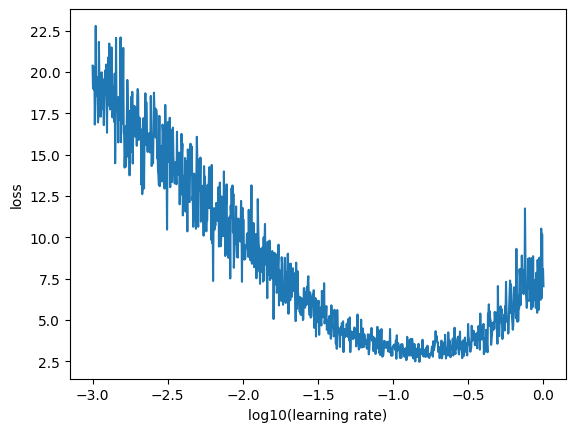

In [68]:
plt.plot(lri, lossi)
plt.xlabel('log10(learning rate)')
plt.ylabel('loss')

# Görev 3c

In [69]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


# Görev 4a

In [70]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C  = torch.randn((27, 2),  generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100,      generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27,       generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

3481

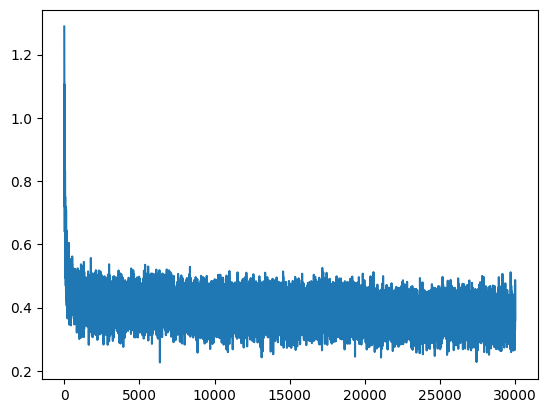

In [71]:
lossi = []
stepi = []

for i in range(30000):

  #Minibatch
  ix = torch.randint(0, Xtr.shape[0], (32,))

  #forward pass
  emb = C[Xtr[ix]] #(32, 3 ,2)
  h = emb.view(-1,6) @ W1 + b1
  h = torch.tanh(h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits , Ytr[ix])

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #gradient descent
  lr = 0.1 if i < 20000 else 0.01   # decay
  for p in parameters:
    p.data += - lr * p.grad

  # tracking stats
  stepi.append(i)
  lossi.append(loss.log10().item())

plt.plot(stepi, lossi)

In [72]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss_tr = F.cross_entropy(logits , Ytr)

emb = C[Xdev]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss_dev = F.cross_entropy(logits , Ydev)

print('train', loss_tr.item(), ' dev', loss_dev.item())

train 2.3711366653442383  dev 2.370622158050537


# Görev 4c

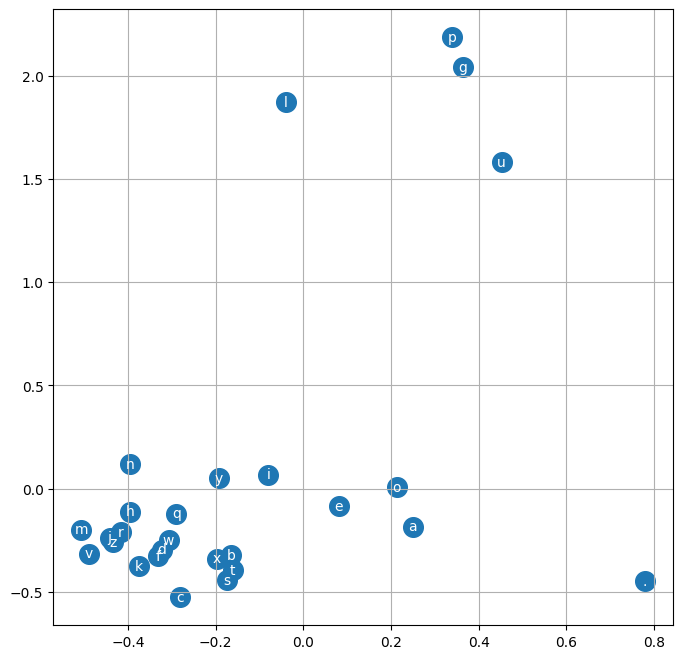

In [73]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

# Görev 4b

In [74]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C  = torch.randn((27, 10),  generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200,      generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27,       generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)

11897

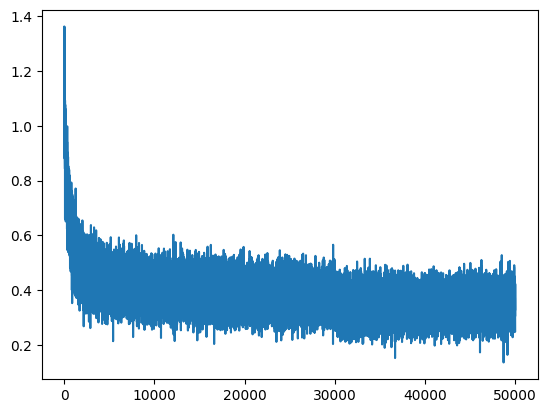

In [75]:
lossi = []
stepi = []

for i in range(50000):

  #Minibatch
  ix = torch.randint(0, Xtr.shape[0], (32,))

  #forward pass
  emb = C[Xtr[ix]] #(32, 3 ,10)
  h = emb.view(-1,30) @ W1 + b1
  h = torch.tanh(h)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits , Ytr[ix])

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #gradient descent
  lr = 0.1 if i < 30000 else 0.01   # decay
  for p in parameters:
    p.data += - lr * p.grad

  # tracking stats
  stepi.append(i)
  lossi.append(loss.log10().item())

plt.plot(stepi, lossi)

In [76]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss_tr = F.cross_entropy(logits , Ytr)

emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss_dev = F.cross_entropy(logits , Ydev)

print('train', loss_tr.item(), ' dev', loss_dev.item())

train 2.22739315032959  dev 2.2477657794952393


# Görev 4d

In [77]:
# sample from the MLP model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])]
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))


    ## Bigram Model Samples
# momasurailezitynn.
# konimittain.
# llayn.
# ka.
# da.
# staiyaubrtthrigotai.
# moliellavo.
# ke.
# teda.'

carmah.
ami.
hari.
kimleige.
tyr.
kansen.
jazhito.
deliah.
jareei.
ner.
kisiciaiivan.
leig.
dham.
jorn.
quinn.
sulin.
alianni.
wane.
maijarynix.
kaeriiluan.


# Görev 5

In [78]:
n_embd = 10
n_hidden = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

11897


In [79]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  h = torch.tanh(embcat @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 26.00469207763672
val 26.010541915893555


In [80]:
n_embd = 10
n_hidden = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

11897


In [81]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  h = torch.tanh(embcat @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.307865619659424
val 3.307642936706543


In [82]:
max_steps = 1
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/      1: 3.3221


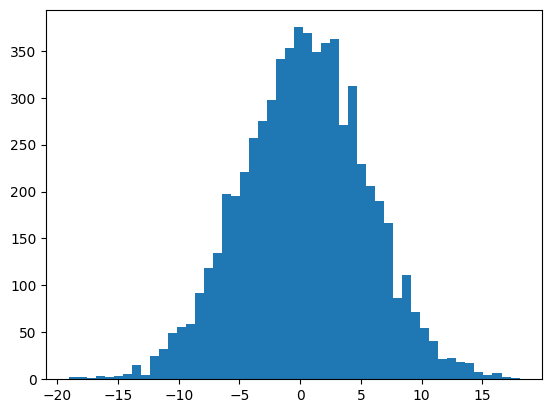

In [83]:
plt.hist(hpreact.view(-1).tolist(), 50);

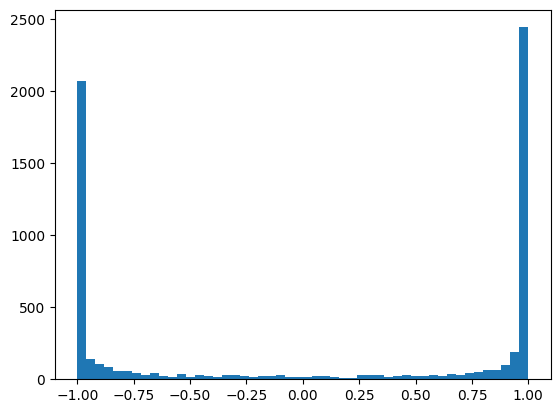

In [84]:
plt.hist(h.view(-1).tolist(), 50);

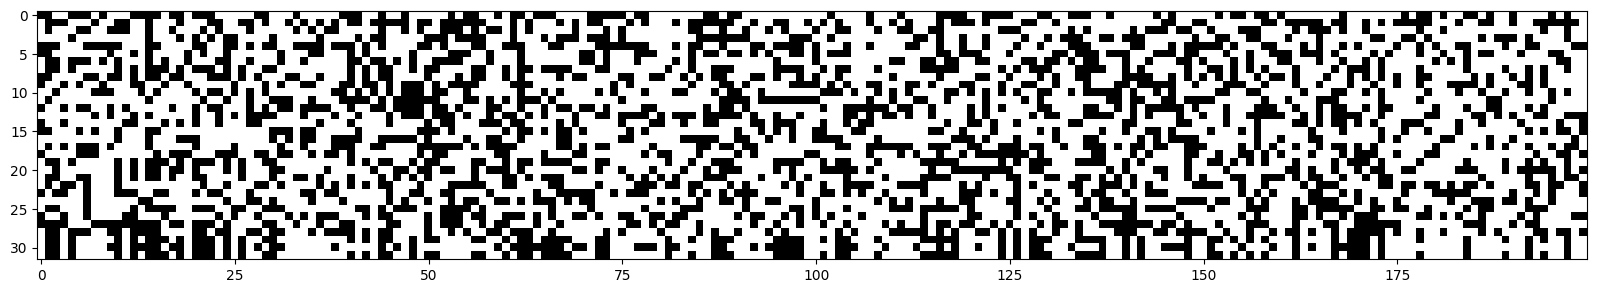

In [85]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [86]:
max_steps = 1000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/   1000: 3.1857


In [87]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  h = torch.tanh(embcat @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.44992995262146
val 2.4558560848236084


In [88]:
n_embd = 10
n_hidden = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

11897


In [89]:
max_steps = 1
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/      1: 3.3179


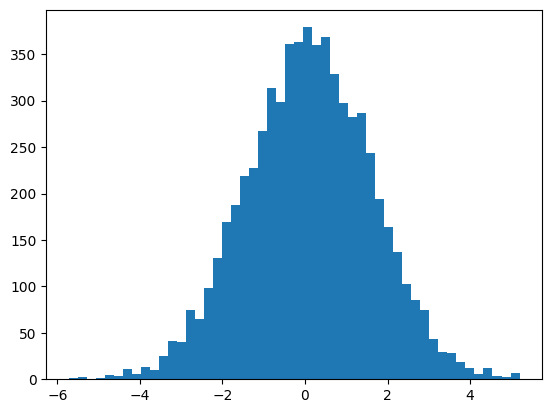

In [90]:
plt.hist(hpreact.view(-1).tolist(), 50);

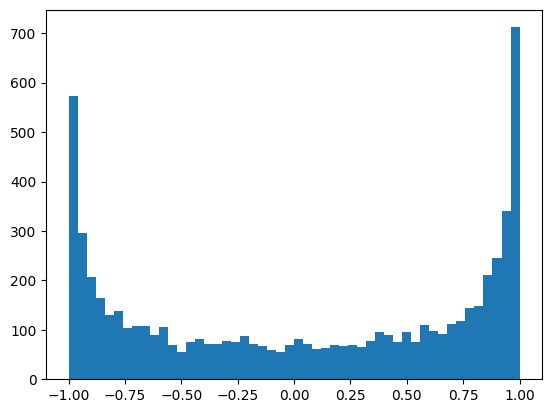

In [91]:
plt.hist(h.view(-1).tolist(), 50);

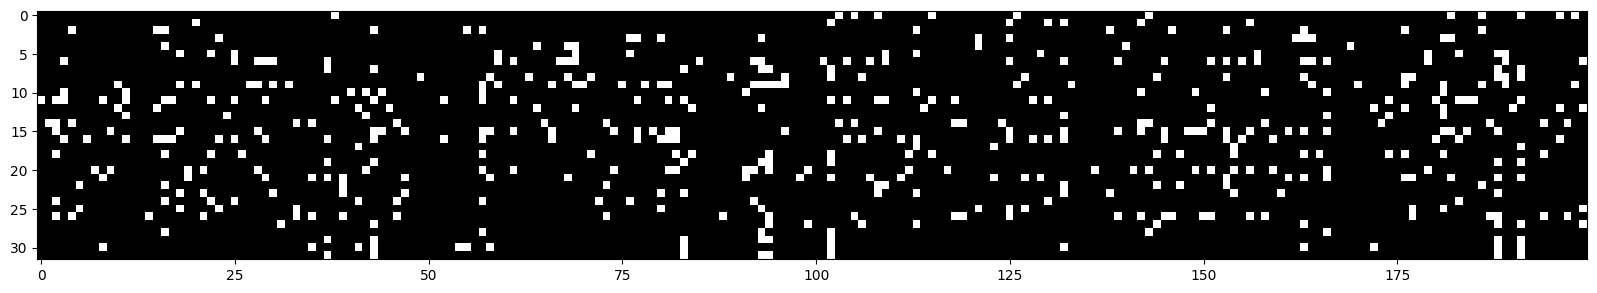

In [92]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [93]:
max_steps = 10000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  10000: 3.2342


In [94]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  h = torch.tanh(embcat @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.2572808265686035
val 2.2812845706939697


# Görev 6

In [95]:
n_embd = 10
n_hidden = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones ((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12297


In [96]:
max_steps = 10000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  10000: 3.3147


In [97]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.2548046112060547
val 2.262031316757202


In [98]:
n_embd = 10
n_hidden = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  # * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g)  # * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones ((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12297


In [99]:
max_steps = 10000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  10000: 3.3147


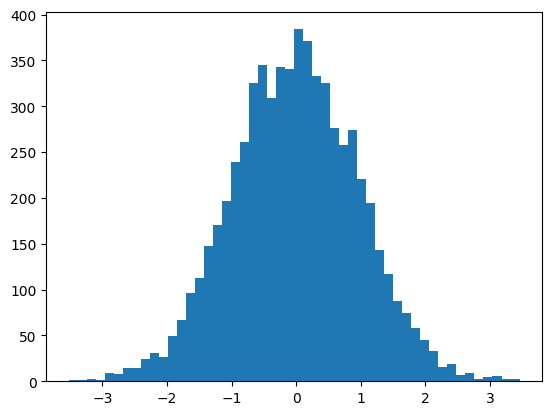

In [100]:
plt.hist(hpreact.view(-1).tolist(), 50);

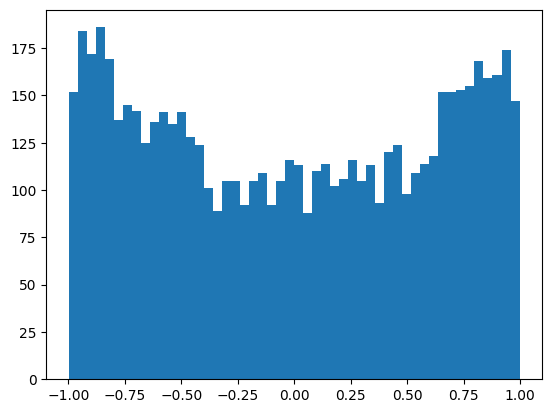

In [101]:
plt.hist(h.view(-1).tolist(), 50);